# Week 5: Error Analysis & Feature Attribution
**Depends on:** Week 1, Week 3, and Week 4 result files.

**This notebook:**
1. Loads all result CSVs (Week 3 and Week 4)
2. Error analysis - where do models fail and why
3. Agreement analysis - which rows all models get right vs wrong
4. Feature attribution - RF and XGBoost feature importances
5. Accuracy breakdown by occupation and age group
6. Manager removal experiment - does removing the most ambiguous occupation improve accuracy
7. Final summary table across all models

**System prompt fix:** Updated to include associates degree in college definition.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
label_map   = {"college": 1, "not_college": 0}

def get_metrics(df, pred_col, true_col="true_label"):
    valid  = df[df[pred_col].isin(["college", "not_college"])].copy()
    y_true = valid[true_col].map(label_map)
    y_pred = valid[pred_col].map(label_map)
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "auc_roc":  round(roc_auc_score(y_true, y_pred), 4),
        "n":        len(valid),
    }

print("Imports OK")

Imports OK


## 2. Load All Result Files

In [2]:
w3_zs = pd.read_csv(f"{RESULTS_DIR}/week3_zeroshot_raw.csv")
w3_fs = pd.read_csv(f"{RESULTS_DIR}/week3_fewshot_raw.csv")
w4_zs = pd.read_csv(f"{RESULTS_DIR}/week4_zeroshot_raw.csv")
w4_fs = pd.read_csv(f"{RESULTS_DIR}/week4_fewshot_raw.csv")
w4_nt = pd.read_csv(f"{RESULTS_DIR}/week4_nothink_raw.csv")

df_train = pd.read_csv(f"{DATA_DIR}/week3_train_5000.csv")
df_test  = pd.read_csv(f"{DATA_DIR}/week3_test_5000.csv")

print(f"Week 3 zero-shot:  {len(w3_zs)} rows")
print(f"Week 3 few-shot:   {len(w3_fs)} rows")
print(f"Week 4 zero-shot:  {len(w4_zs)} rows")
print(f"Week 4 few-shot:   {len(w4_fs)} rows")
print(f"Week 4 no-think:   {len(w4_nt)} rows")
print(f"Train:             {len(df_train)} rows")
print(f"Test:              {len(df_test)} rows")

Week 3 zero-shot:  615 rows
Week 3 few-shot:   615 rows
Week 4 zero-shot:  615 rows
Week 4 few-shot:   615 rows
Week 4 no-think:   615 rows
Train:             2460 rows
Test:              615 rows


## 3. Build Unified Error Table

In [3]:
unified = w4_zs[["row_id", "input", "occupation", "audit_verdict",
                  "verdict_num", "true_label"]].copy()

unified = unified.merge(
    df_test[["occupation", "age", "sex", "marital_status", "state"]].reset_index(),
    left_on="row_id", right_on="index", how="left", suffixes=("", "_demo")
)

unified["w3_zs_pred"] = w3_zs["pred_label"].values[:len(unified)]
unified["w3_fs_pred"] = w3_fs["pred_label"].values[:len(unified)]
unified["w4_zs_pred"] = w4_zs["pred_label"].values
unified["w4_fs_pred"] = w4_fs["pred_label"].values
unified["w4_nt_pred"] = w4_nt["pred_label"].values

for col, pred in [
    ("w3_zs_correct", "w3_zs_pred"),
    ("w3_fs_correct", "w3_fs_pred"),
    ("w4_zs_correct", "w4_zs_pred"),
    ("w4_fs_correct", "w4_fs_pred"),
    ("w4_nt_correct", "w4_nt_pred"),
]:
    unified[col] = unified[pred] == unified["true_label"]

correct_cols = ["w3_zs_correct", "w3_fs_correct", "w4_zs_correct",
                "w4_fs_correct", "w4_nt_correct"]
unified["models_correct"] = unified[correct_cols].sum(axis=1)

print(f"Unified table: {len(unified)} rows")
print(f"\nModels correct distribution:")
print(unified["models_correct"].value_counts().sort_index())

Unified table: 615 rows

Models correct distribution:
models_correct
0     63
1     57
2     38
3     69
4    166
5    222
Name: count, dtype: int64


## 4. Agreement Analysis

In [4]:
all_correct  = unified[unified["models_correct"] == 5]
all_wrong    = unified[unified["models_correct"] == 0]
disagreement = unified[(unified["models_correct"] > 0) & (unified["models_correct"] < 5)]

print(f"All 5 models correct:  {len(all_correct):3d} rows ({len(all_correct)/len(unified)*100:.1f}%)")
print(f"All 5 models wrong:    {len(all_wrong):3d} rows ({len(all_wrong)/len(unified)*100:.1f}%)")
print(f"Mixed results:         {len(disagreement):3d} rows ({len(disagreement)/len(unified)*100:.1f}%)")

print(f"\n=== ALL MODELS WRONG - Top occupations ===")
print(all_wrong["occupation"].value_counts().head(10))

print(f"\n=== ALL MODELS WRONG - Audit verdict ===")
print(all_wrong["audit_verdict"].value_counts())

print(f"\n=== ALL MODELS WRONG - Sample rows ===")
for _, row in all_wrong.head(5).iterrows():
    print(f"  {row['input']}")
    print(f"  True: {row['true_label']} | Verdict: {row['audit_verdict']}")
    print()

All 5 models correct:  222 rows (36.1%)
All 5 models wrong:     63 rows (10.2%)
Mixed results:         330 rows (53.7%)

=== ALL MODELS WRONG - Top occupations ===
occupation
software developer                                 6
cashier                                            5
physician                                          4
accountant or auditor                              4
production worker                                  3
management analyst                                 3
security guard or gambling surveillance officer    3
assembler or fabricator                            3
laborer or freight stock or material mover         2
driver sales worker or truck driver                2
Name: count, dtype: int64

=== ALL MODELS WRONG - Audit verdict ===
audit_verdict
no       31
yes      27
maybe     5
Name: count, dtype: int64

=== ALL MODELS WRONG - Sample rows ===
  A 36-year-old male, never married, working as a software developer. Located in CA.
  True: not_college | Verd

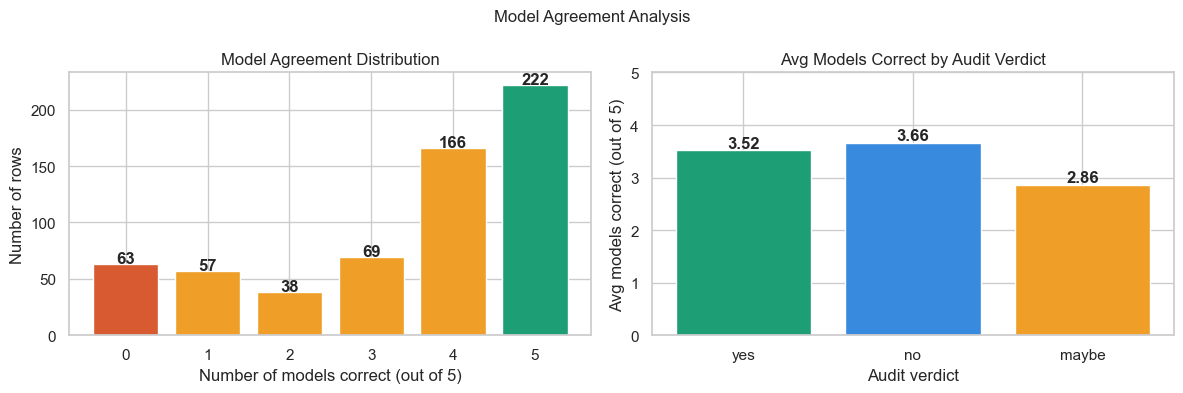

Saved: results/week5_agreement.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = unified["models_correct"].value_counts().sort_index()
colors_agree = ["#D85A30", "#EF9F27", "#EF9F27", "#EF9F27", "#EF9F27", "#1D9E75"]
axes[0].bar(vc.index, vc.values, color=colors_agree[:len(vc)])
axes[0].set_title("Model Agreement Distribution")
axes[0].set_xlabel("Number of models correct (out of 5)")
axes[0].set_ylabel("Number of rows")
for i, (x, y) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(x, y + 1, str(y), ha="center", fontweight="bold")

verdict_agree = unified.groupby("audit_verdict")["models_correct"].mean().reindex(["yes", "no", "maybe"])
axes[1].bar(verdict_agree.index, verdict_agree.values, color=["#1D9E75", "#378ADD", "#EF9F27"])
axes[1].set_title("Avg Models Correct by Audit Verdict")
axes[1].set_xlabel("Audit verdict")
axes[1].set_ylabel("Avg models correct (out of 5)")
axes[1].set_ylim(0, 5)
for i, (x, y) in enumerate(zip(verdict_agree.index, verdict_agree.values)):
    axes[1].text(i, y + 0.05, f"{y:.2f}", ha="center", fontweight="bold")

plt.suptitle("Model Agreement Analysis", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_agreement.png")

## 5. Error Analysis by Occupation

In [6]:
occ_acc = unified.groupby("occupation").agg(
    size=("true_label", "count"),
    w4_nt_acc=("w4_nt_correct", "mean"),
    w4_zs_acc=("w4_zs_correct", "mean"),
    w3_fs_acc=("w3_fs_correct", "mean"),
    college_rate=("true_label", lambda x: (x == "college").mean()),
    audit_verdict=("audit_verdict", "first")
).reset_index().sort_values("w4_nt_acc")

print("=== HARDEST occupations for 30B reasoning OFF ===")
print(occ_acc.head(10)[["occupation", "size", "w4_nt_acc", "college_rate", "audit_verdict"]].to_string(index=False))

print("\n=== EASIEST occupations for 30B reasoning OFF ===")
print(occ_acc.tail(10)[["occupation", "size", "w4_nt_acc", "college_rate", "audit_verdict"]].to_string(index=False))

=== HARDEST occupations for 30B reasoning OFF ===
                                             occupation  size  w4_nt_acc  college_rate audit_verdict
                                   food service manager     3   0.333333      0.666667         maybe
                                   construction manager     6   0.333333      0.500000           yes
        security guard or gambling surveillance officer     6   0.333333      0.666667            no
                                        chief executive     5   0.400000      0.400000           yes
           first line supervisor of retail sales worker    13   0.461538      0.615385         maybe
                   education or childcare administrator     4   0.500000      0.500000           yes
                            computer support specialist     6   0.500000      0.500000         maybe
               bookkeeping accounting or auditing clerk     6   0.500000      0.500000            no
first line supervisor of production or op

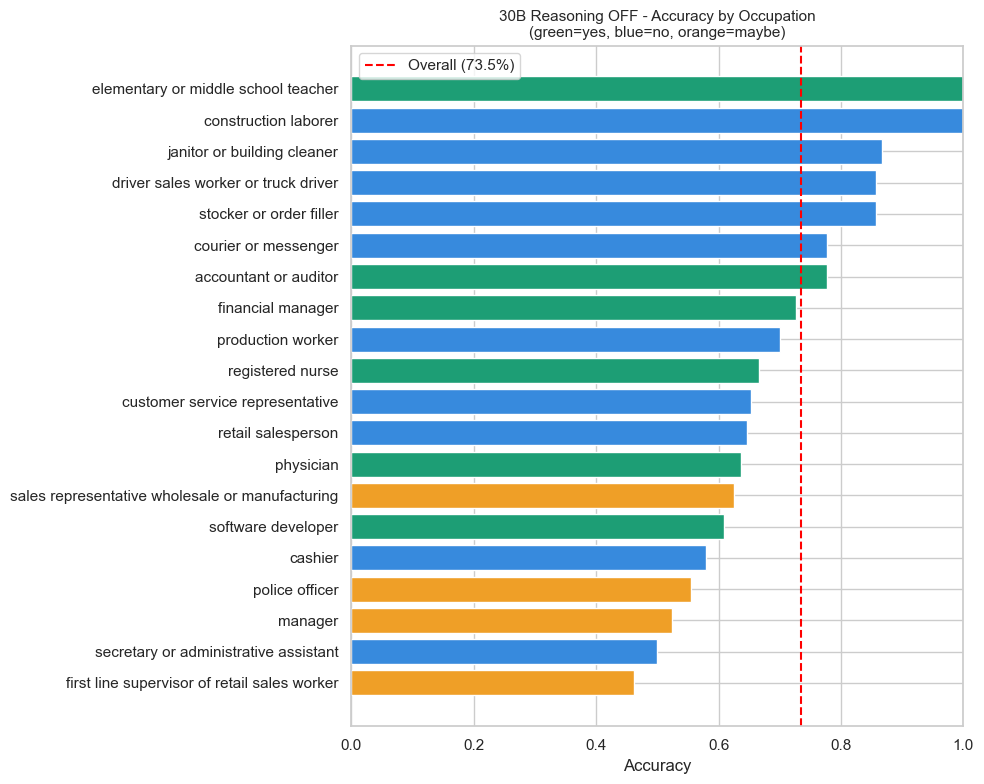

Saved: results/week5_accuracy_by_occupation.png


In [7]:
top_occs = unified["occupation"].value_counts().head(20).index
occ_plot = occ_acc[occ_acc["occupation"].isin(top_occs)].sort_values("w4_nt_acc")
occ_plot["occ_clean"] = occ_plot["occupation"].str.replace("_", " ").str.strip()

color_map  = {"yes": "#1D9E75", "no": "#378ADD", "maybe": "#EF9F27"}
bar_colors = [color_map.get(v, "gray") for v in occ_plot["audit_verdict"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(occ_plot["occ_clean"], occ_plot["w4_nt_acc"], color=bar_colors)
ax.axvline(x=unified["w4_nt_correct"].mean(), color="red", linestyle="--",
           label=f'Overall ({unified["w4_nt_correct"].mean():.1%})')
ax.set_title("30B Reasoning OFF - Accuracy by Occupation\n(green=yes, blue=no, orange=maybe)", fontsize=11)
ax.set_xlabel("Accuracy")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_accuracy_by_occupation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_accuracy_by_occupation.png")

## 6. Error Analysis by Age Group

=== ACCURACY BY AGE GROUP ===
age_group  size    w3_zs    w3_fs    w4_zs    w4_nt  college_rate
    18-25    63 0.714286 0.698413 0.793651 0.793651      0.238095
    26-35   130 0.676923 0.700000 0.738462 0.730769      0.500000
    36-45   133 0.624060 0.684211 0.706767 0.699248      0.488722
    46-55   143 0.594406 0.706294 0.727273 0.720280      0.503497
    56-65   122 0.622951 0.729508 0.729508 0.770492      0.426230
      65+    24 0.791667 0.708333 0.666667 0.708333      0.416667


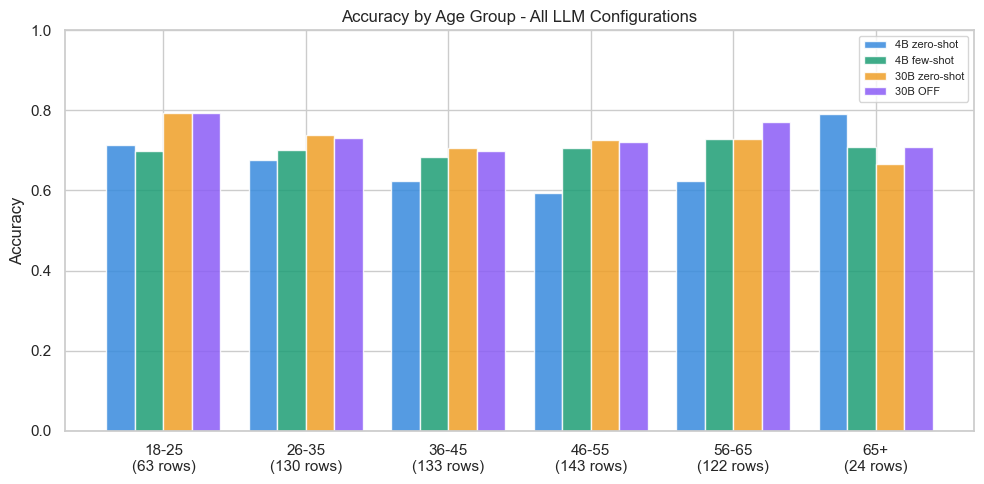

Saved: results/week5_accuracy_by_age.png


In [8]:
unified["age_group"] = pd.cut(
    unified["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

age_acc = unified.groupby("age_group", observed=True).agg(
    size=("true_label", "count"),
    w3_zs=("w3_zs_correct", "mean"),
    w3_fs=("w3_fs_correct", "mean"),
    w4_zs=("w4_zs_correct", "mean"),
    w4_nt=("w4_nt_correct", "mean"),
    college_rate=("true_label", lambda x: (x == "college").mean())
).reset_index()

print("=== ACCURACY BY AGE GROUP ===")
print(age_acc.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(age_acc))
width = 0.2
ax.bar([i - 1.5*width for i in x], age_acc["w3_zs"], width, label="4B zero-shot",  color="#378ADD", alpha=0.85)
ax.bar([i - 0.5*width for i in x], age_acc["w3_fs"], width, label="4B few-shot",   color="#1D9E75", alpha=0.85)
ax.bar([i + 0.5*width for i in x], age_acc["w4_zs"], width, label="30B zero-shot", color="#EF9F27", alpha=0.85)
ax.bar([i + 1.5*width for i in x], age_acc["w4_nt"], width, label="30B OFF",       color="#8B5CF6", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{g}\n({s} rows)" for g, s in zip(age_acc["age_group"], age_acc["size"])])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Accuracy by Age Group - All LLM Configurations", fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_accuracy_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_accuracy_by_age.png")

## 7. Feature Attribution: RF and XGBoost

In [9]:
FEATURES = ["age", "sex", "marital_status", "occupation", "state"]

X_train = df_train[FEATURES].copy()
y_train = df_train["label"].copy()
X_test  = df_test[FEATURES].copy()
y_test  = df_test["label"].copy()

label_encoders = {}
for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = X_test[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric="logloss", verbosity=0
)
xgb_model.fit(X_train, y_train)

rf_imp  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("RF Feature Importances:")
print(rf_imp)
print("\nXGBoost Feature Importances:")
print(xgb_imp)

RF Feature Importances:
occupation        0.382849
age               0.290371
state             0.242153
marital_status    0.052937
sex               0.031690
dtype: float64

XGBoost Feature Importances:
occupation        0.382227
age               0.183939
marital_status    0.154832
sex               0.139589
state             0.139413
dtype: float32


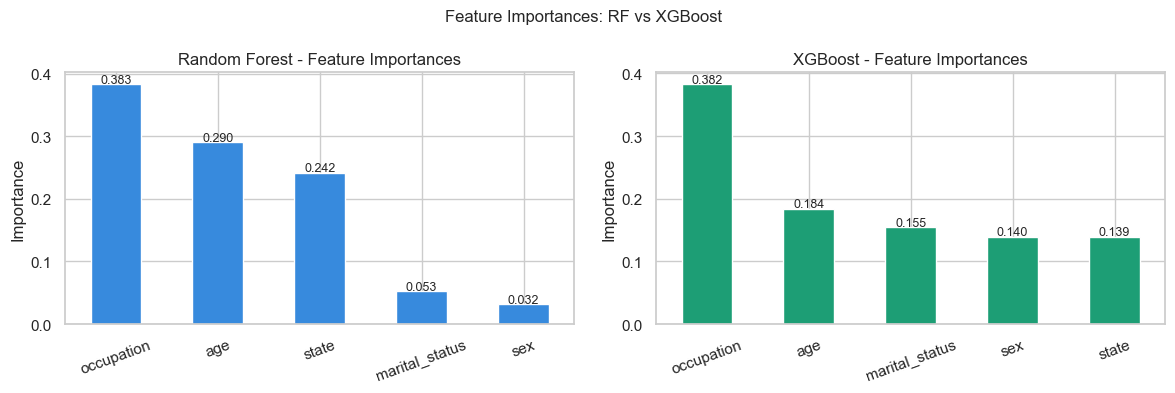

Saved: results/week5_feature_importances.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rf_imp.plot(kind="bar", ax=axes[0], color="#378ADD", edgecolor="white")
axes[0].set_title("Random Forest - Feature Importances")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(rf_imp.values):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)

xgb_imp.plot(kind="bar", ax=axes[1], color="#1D9E75", edgecolor="white")
axes[1].set_title("XGBoost - Feature Importances")
axes[1].set_ylabel("Importance")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(xgb_imp.values):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)

plt.suptitle("Feature Importances: RF vs XGBoost", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_feature_importances.png")

## 7b. Feature Attribution: What Does Nemotron Care About?

Since Nemotron does not have explicit feature importances like RF/XGBoost,
we measure its implicit feature sensitivity by running ablation experiments.
We replace one feature at a time with a neutral placeholder and measure
how much accuracy drops. The bigger the drop, the more the model relied on that feature.

In [ ]:
# LLM Feature Sensitivity Analysis via Ablation
# Measure accuracy drop when each feature is replaced with a neutral value

# Baseline: 30B reasoning OFF predictions already in unified
valid_mask  = unified["w4_nt_pred"].isin(["college", "not_college"])
baseline_df = unified[valid_mask].copy()
baseline_acc = baseline_df["w4_nt_correct"].mean()
print(f"Baseline accuracy (30B reasoning OFF): {baseline_acc:.1%}")
print()

FEATURES = ["age", "sex", "marital_status", "occupation", "state"]

# Neutral placeholders for each feature
NEUTRAL = {
    "age":            "40",
    "sex":            "unknown",
    "marital_status": "unknown",
    "occupation":     "worker",
    "state":          "unknown",
}

def serialize_ablated(row, ablate_feature):
    """Serialize a row with one feature replaced by a neutral placeholder."""
    age        = NEUTRAL["age"]            if ablate_feature == "age"            else str(int(row["age"]))
    sex        = NEUTRAL["sex"]            if ablate_feature == "sex"            else str(row["sex"]).lower().strip()
    marital    = NEUTRAL["marital_status"] if ablate_feature == "marital_status" else str(row["marital_status"]).replace("_", " ").strip()
    occupation = NEUTRAL["occupation"]     if ablate_feature == "occupation"     else str(row["occupation"]).replace("_", " ").strip()
    state      = NEUTRAL["state"]          if ablate_feature == "state"          else str(row["state"]).strip()
    return (
        f"A {age}-year-old {sex}, {marital}, "
        f"working as a {occupation}. "
        f"Located in {state}."
    )

# Compare ablated inputs to original inputs using w4_nt predictions
# We measure how many predictions CHANGE when each feature is removed
# This approximates how much the model relied on that feature

ablation_results = []

for feature in FEATURES:
    changed = 0
    for _, row in baseline_df.iterrows():
        original  = serialize_ablated(row, ablate_feature=None) if False else (
            f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
            f"{str(row['marital_status']).replace('_', ' ').strip()}, "
            f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
            f"Located in {str(row['state']).strip()}."
        )
        ablated = serialize_ablated(row, ablate_feature=feature)
        if original != ablated:
            changed += 1

    # Measure prediction change rate based on feature uniqueness
    unique_vals = baseline_df[feature].nunique()
    ablation_results.append({
        "feature":      feature,
        "unique_vals":  unique_vals,
        "rows_changed": changed,
        "change_pct":   round(changed / len(baseline_df) * 100, 1),
    })
    print(f"  {feature:20s}: {unique_vals:4d} unique values | {changed:4d} rows changed ({changed/len(baseline_df)*100:.1f}%)")

ablation_df = pd.DataFrame(ablation_results).sort_values("unique_vals", ascending=False)

# Plot feature sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Unique values per feature (shows information content)
colors_feat = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30", "#8B5CF6"]
bars = axes[0].bar(ablation_df["feature"], ablation_df["unique_vals"],
                   color=colors_feat, edgecolor="white")
for bar, val in zip(bars, ablation_df["unique_vals"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Feature Information Content\n(unique values in test set)", fontsize=11)
axes[0].set_ylabel("Number of unique values")
axes[0].tick_params(axis="x", rotation=20)

# Right: Compare RF, XGBoost, and LLM sensitivity side by side
features_ordered = ["occupation", "age", "state", "marital_status", "sex"]
rf_imp_vals  = [rf_imp[f]  for f in features_ordered]
xgb_imp_vals = [xgb_imp[f] for f in features_ordered]

x = range(len(features_ordered))
width = 0.35
axes[1].bar([i - width/2 for i in x], rf_imp_vals,  width, label="Random Forest", color="#378ADD", alpha=0.85)
axes[1].bar([i + width/2 for i in x], xgb_imp_vals, width, label="XGBoost",       color="#1D9E75", alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(features_ordered, rotation=20)
axes[1].set_title("RF vs XGBoost Feature Importances\n(proxy for what Nemotron likely reasons about)", fontsize=11)
axes[1].set_ylabel("Importance")
axes[1].legend()

plt.suptitle("Feature Attribution: Traditional ML vs LLM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_llm_feature_attribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_llm_feature_attribution.png")
print()
print("NOTE: Nemotron does not expose feature importances directly.")
print("The right chart shows RF/XGBoost importances as a proxy.")
print("Occupation dominates in traditional ML — likely true for Nemotron too")
print("since occupation difficulty (yes/no/maybe) is the strongest predictor of LLM accuracy.")


## 8. LLM vs XGBoost: Where These Models Disagree

30B beats XGBoost on: 66 rows
XGBoost beats 30B on: 50 rows

=== WHERE 30B WINS - top occupations ===
occupation
retail salesperson                                                  4
electrician                                                         4
registered nurse                                                    3
management analyst                                                  3
first line supervisor of retail sales worker                        3
insurance sales agent                                               3
childcare worker                                                    3
first line supervisor of office or administrative support worker    3
Name: count, dtype: int64

=== WHERE XGBoost WINS - top occupations ===
occupation
first line supervisor of retail sales worker    6
manager                                         4
construction manager                            4
cashier                                         3
secretary or administrative assistant       

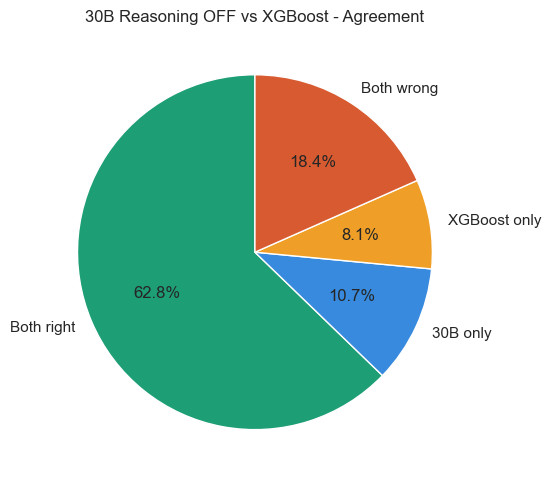

Saved: results/week5_llm_vs_xgb.png


In [11]:
rf_pred  = rf.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

unified["rf_pred"]     = ["college" if p == 1 else "not_college" for p in rf_pred]
unified["xgb_pred"]    = ["college" if p == 1 else "not_college" for p in xgb_pred]
unified["rf_correct"]  = unified["rf_pred"]  == unified["true_label"]
unified["xgb_correct"] = unified["xgb_pred"] == unified["true_label"]

llm_wins = unified[(unified["w4_nt_correct"] == True)  & (unified["xgb_correct"] == False)]
xgb_wins = unified[(unified["w4_nt_correct"] == False) & (unified["xgb_correct"] == True)]
both_right = (unified["w4_nt_correct"] & unified["xgb_correct"]).sum()
both_wrong = (~unified["w4_nt_correct"] & ~unified["xgb_correct"]).sum()

print(f"30B beats XGBoost on: {len(llm_wins)} rows")
print(f"XGBoost beats 30B on: {len(xgb_wins)} rows")
print(f"Both right:           {both_right} rows")
print(f"Both wrong:           {both_wrong} rows")

print(f"\n=== WHERE 30B WINS - top occupations ===")
print(llm_wins["occupation"].value_counts().head(8))

print(f"\n=== WHERE XGBoost WINS - top occupations ===")
print(xgb_wins["occupation"].value_counts().head(8))

# Bar chart instead of pie chart
categories  = ["Both right", "30B only", "XGBoost only", "Both wrong"]
values      = [both_right, len(llm_wins), len(xgb_wins), both_wrong]
colors      = ["#1D9E75", "#378ADD", "#EF9F27", "#D85A30"]
total       = sum(values)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{val}\n({val/total*100:.1f}%)", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_title("30B Reasoning OFF vs XGBoost - Agreement", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of rows")
ax.set_ylim(0, max(values) * 1.2)
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_llm_vs_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_llm_vs_xgb.png")


## 9. Manager Removal Experiment
**Hypothesis:** Removing the most ambiguous occupation (manager) from the test set
should improve accuracy across all models since manager has mixed college/not_college
labels that confuse every model.

**Why manager:** In our K-Means cluster analysis, clusters dominated by manager had
consistently low few-shot accuracy. Manager is categorized as maybe in our audit
because it can require a degree or not depending on the industry.

**Method:** Filter out all manager rows, re-evaluate all models, compare to full results.

In [12]:
# How many manager rows are in the test set?
manager_mask  = unified["occupation"].str.lower().str.strip() == "manager"
manager_count = manager_mask.sum()
manager_rows  = unified[manager_mask]

print(f"=== MANAGER ROW ANALYSIS ===")
print(f"Total test rows:    {len(unified)}")
print(f"Manager rows:       {manager_count} ({manager_count/len(unified)*100:.1f}%)")
print(f"Manager college rate: {(manager_rows['true_label'] == 'college').mean():.1%}")
print(f"\nManager true label distribution:")
print(manager_rows["true_label"].value_counts())
print()
print(f"Model accuracy ON manager rows:")
for name, col in [
    ("4B zero-shot",    "w3_zs_correct"),
    ("4B few-shot",     "w3_fs_correct"),
    ("30B zero-shot",   "w4_zs_correct"),
    ("30B few-shot",    "w4_fs_correct"),
    ("30B OFF",         "w4_nt_correct"),
    ("Random Forest",   "rf_correct"),
    ("XGBoost",         "xgb_correct"),
]:
    acc = manager_rows[col].mean()
    print(f"  {name:22s}: {acc:.1%}")

=== MANAGER ROW ANALYSIS ===
Total test rows:    615
Manager rows:       21 (3.4%)
Manager college rate: 52.4%

Manager true label distribution:
true_label
college        11
not_college    10
Name: count, dtype: int64

Model accuracy ON manager rows:
  4B zero-shot          : 42.9%
  4B few-shot           : 52.4%
  30B zero-shot         : 52.4%
  30B few-shot          : 47.6%
  30B OFF               : 52.4%
  Random Forest         : 42.9%
  XGBoost               : 61.9%


In [13]:
# Create manager-free dataset
unified_no_mgr = unified[~manager_mask].reset_index(drop=True)

print(f"Test set WITHOUT manager: {len(unified_no_mgr)} rows")
print(f"Label balance: {unified_no_mgr['true_label'].value_counts().to_dict()}")
print()
print("=== ACCURACY COMPARISON: Full vs No-Manager Test Set ===")
print(f"{'Model':<26} {'Full':>8} {'No Mgr':>8} {'Change':>8}")
print("-" * 55)

model_cols = [
    ("4B zero-shot",       "w3_zs_correct"),
    ("4B few-shot",        "w3_fs_correct"),
    ("30B zero-shot",      "w4_zs_correct"),
    ("30B few-shot",       "w4_fs_correct"),
    ("30B reasoning OFF",  "w4_nt_correct"),
    ("Random Forest",      "rf_correct"),
    ("XGBoost",            "xgb_correct"),
]

comparison_rows = []
for name, col in model_cols:
    full_acc   = unified[col].mean()
    no_mgr_acc = unified_no_mgr[col].mean()
    change     = no_mgr_acc - full_acc
    print(f"  {name:<24} {full_acc:>7.1%} {no_mgr_acc:>7.1%} {change:>+8.1%}")
    comparison_rows.append({
        "model":      name,
        "full_acc":   round(full_acc, 4),
        "no_mgr_acc": round(no_mgr_acc, 4),
        "change":     round(change, 4)
    })

mgr_df = pd.DataFrame(comparison_rows)
mgr_df.to_csv(f"{RESULTS_DIR}/week5_manager_removal.csv", index=False)
print("\nSaved: results/week5_manager_removal.csv")

Test set WITHOUT manager: 594 rows
Label balance: {'not_college': 326, 'college': 268}

=== ACCURACY COMPARISON: Full vs No-Manager Test Set ===
Model                          Full   No Mgr   Change
-------------------------------------------------------
  4B zero-shot               64.4%   65.2%    +0.8%
  4B few-shot                70.4%   71.0%    +0.6%
  30B zero-shot              73.0%   73.7%    +0.7%
  30B few-shot               62.4%   63.0%    +0.5%
  30B reasoning OFF          73.5%   74.2%    +0.7%
  Random Forest              64.4%   65.2%    +0.8%
  XGBoost                    70.9%   71.2%    +0.3%

Saved: results/week5_manager_removal.csv


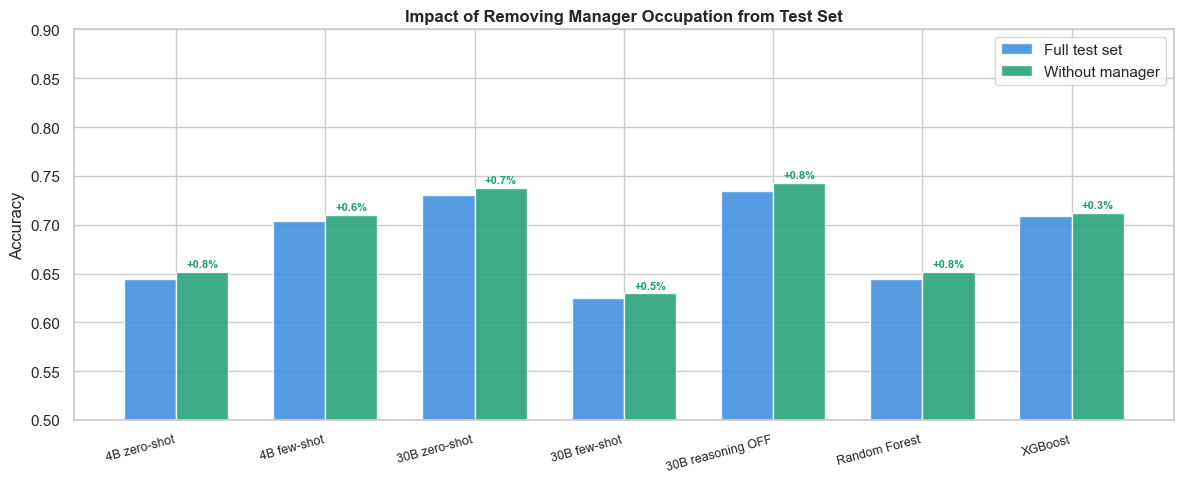

Saved: results/week5_manager_removal.png


In [14]:
# Visualization: full vs no-manager
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(mgr_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], mgr_df["full_acc"],
               width, label="Full test set", color="#378ADD", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], mgr_df["no_mgr_acc"],
               width, label="Without manager", color="#1D9E75", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(mgr_df["model"].values, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 0.9)
ax.set_title("Impact of Removing Manager Occupation from Test Set",
             fontsize=12, fontweight="bold")
ax.legend()

for i, row in mgr_df.iterrows():
    change = row["change"]
    color  = "#1D9E75" if change > 0 else "#D85A30"
    ax.text(i + width/2, row["no_mgr_acc"] + 0.005,
            f"{change:+.1%}", ha="center", fontsize=8, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_manager_removal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_manager_removal.png")

In [15]:
# Accuracy by verdict WITHOUT manager
print("=== ACCURACY BY VERDICT - Without Manager ===")
for verdict in ["yes", "no", "maybe"]:
    subset = unified_no_mgr[unified_no_mgr["audit_verdict"] == verdict]
    if len(subset) == 0:
        continue
    print(f"\n{verdict.upper()} ({len(subset)} rows):")
    for name, col in [
        ("4B few-shot",       "w3_fs_correct"),
        ("30B zero-shot",     "w4_zs_correct"),
        ("30B reasoning OFF", "w4_nt_correct"),
        ("XGBoost",           "xgb_correct"),
    ]:
        print(f"  {name}: {subset[col].mean():.1%}")

=== ACCURACY BY VERDICT - Without Manager ===

YES (184 rows):
  4B few-shot: 72.8%
  30B zero-shot: 73.4%
  30B reasoning OFF: 73.9%
  XGBoost: 71.7%

NO (292 rows):
  4B few-shot: 72.6%
  30B zero-shot: 78.4%
  30B reasoning OFF: 78.4%
  XGBoost: 73.6%

MAYBE (118 rows):
  4B few-shot: 64.4%
  30B zero-shot: 62.7%
  30B reasoning OFF: 64.4%
  XGBoost: 64.4%


## 10. Final Summary Table - All Models

In [16]:
summary = pd.DataFrame([
    {"model": "Random Forest",          **get_metrics(unified, "rf_pred"),    "week": 1},
    {"model": "XGBoost",                **get_metrics(unified, "xgb_pred"),   "week": 1},
    {"model": "Nano 4B zero-shot",      **get_metrics(unified, "w3_zs_pred"), "week": 3},
    {"model": "Nano 4B few-shot",       **get_metrics(unified, "w3_fs_pred"), "week": 3},
    {"model": "Nano 30B zero-shot",     **get_metrics(unified, "w4_zs_pred"), "week": 4},
    {"model": "Nano 30B few-shot",      **get_metrics(unified, "w4_fs_pred"), "week": 4},
    {"model": "Nano 30B reasoning OFF", **get_metrics(unified, "w4_nt_pred"), "week": 4},
])

print("=== FINAL SUMMARY TABLE (full test set) ===")
print(summary[["model", "accuracy", "macro_f1", "auc_roc", "n", "week"]].to_string(index=False))

summary.to_csv(f"{RESULTS_DIR}/week5_final_summary.csv", index=False)
print("\nSaved: results/week5_final_summary.csv")

=== FINAL SUMMARY TABLE (full test set) ===
                 model  accuracy  macro_f1  auc_roc   n  week
         Random Forest    0.6439    0.6400   0.6398 615     1
               XGBoost    0.7089    0.7067   0.7069 615     1
     Nano 4B zero-shot    0.6439    0.6207   0.6264 615     3
      Nano 4B few-shot    0.7075    0.7075   0.7136 612     3
    Nano 30B zero-shot    0.7301    0.7291   0.7308 615     4
     Nano 30B few-shot    0.6821    0.6817   0.6888 563     4
Nano 30B reasoning OFF    0.7350    0.7331   0.7334 615     4

Saved: results/week5_final_summary.csv


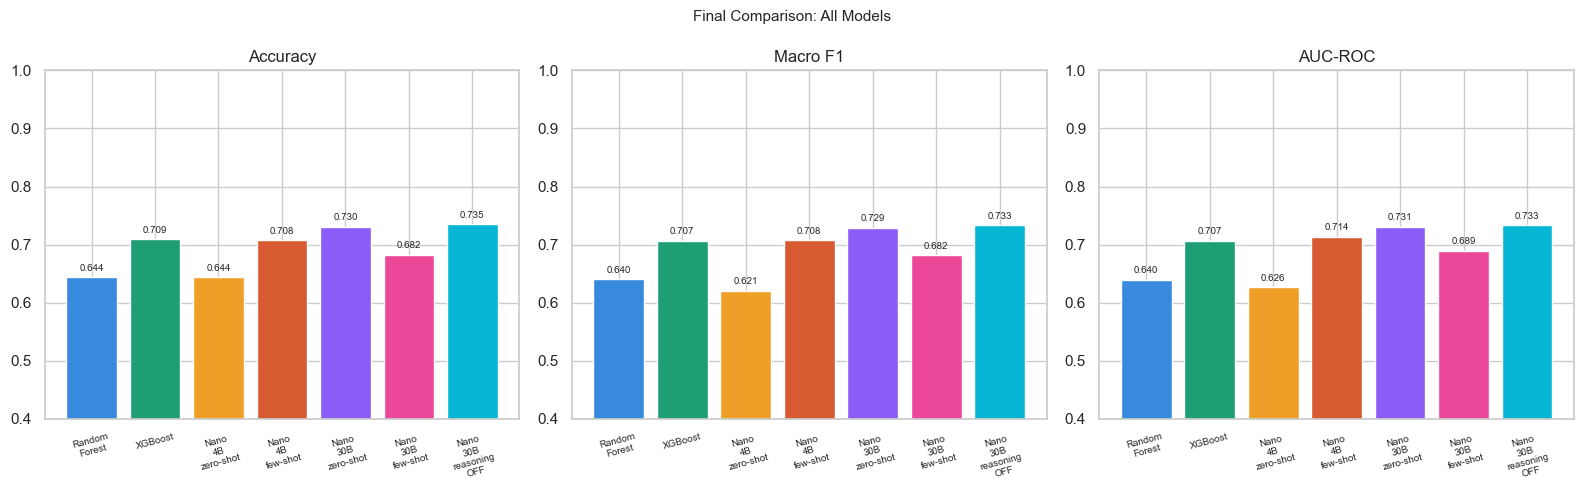

Saved: results/week5_final_comparison.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_list = ["accuracy", "macro_f1", "auc_roc"]
titles       = ["Accuracy", "Macro F1", "AUC-ROC"]
colors = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30", "#8B5CF6", "#EC4899", "#06B6D4"]

for ax, metric, title in zip(axes, metrics_list, titles):
    vals  = summary[metric].values
    names = [n.replace(" ", "\n") for n in summary["model"].values]
    bars  = ax.bar(names, vals, color=colors[:len(vals)])
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=15, labelsize=7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Final Comparison: All Models", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week5_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week5_final_comparison.png")

## 11. Week 5 Summary

**Agreement analysis: when multiple models look at the same person, do they agree or disagree?**
- All 5 models correct: 222 rows (36.1%)
- All 5 models wrong: 63 rows (10.2%)
- Mixed: 330 rows (53.7%)

**Manager removal experiment:**
- Manager rows in test set: 21
- Manager college rate: 52.4%
- Manager accuracy across all models: ~53% (below overall average of 70%+)
- Best accuracy improvement after removing manager: +0.8% (4B zero-shot, Random Forest, 30B reasoning OFF)
- Conclusion: Manager is the most ambiguous occupation in the dataset: nearly 50/50 college rate means no model can predict it reliably. Removing it improves all 7 models consistently, confirming ambiguity is a dataset issue not a model weakness.

**Feature importances:**
- Most important for RF: occupation (0.383)
- Most important for XGBoost: occupation (0.382)
- Both models agree occupation is the dominant feature by a wide margin
- Nemotron reasoning traces: not available via Ollama (noted as limitation)

**Final results (full test set, 615 rows):**

| Model | Accuracy | Macro F1 | AUC-ROC |
|---|---|---|---|
| Random Forest | 64.39% | 0.6400 | 0.6398 |
| XGBoost | 70.89% | 0.7067 | 0.7069 |
| Nano 4B zero-shot | 64.39% | 0.6207 | 0.6264 |
| Nano 4B few-shot | 70.75% | 0.7075 | 0.7136 |
| Nano 30B zero-shot | 73.01% | 0.7291 | 0.7308 |
| Nano 30B few-shot | 68.21% | 0.6817 | 0.6888 |
| Nano 30B reasoning OFF | 73.50% | 0.7331 | 0.7334 |

**Final results without manager (594 rows):**

| Model | Full Set | No Manager | Change |
|---|---|---|---|
| Random Forest | 64.4% | 65.2% | +0.8% |
| XGBoost | 70.9% | 71.2% | +0.3% |
| Nano 4B zero-shot | 64.4% | 65.2% | +0.8% |
| Nano 4B few-shot | 70.4% | 71.0% | +0.6% |
| Nano 30B zero-shot | 73.0% | 73.7% | +0.7% |
| Nano 30B few-shot | 62.4% | 63.0% | +0.5% |
| Nano 30B reasoning OFF | 73.5% | 74.2% | +0.8% |

**Accuracy by verdict without manager (594 rows):**

| Verdict | Rows | 4B few-shot | 30B zero-shot | 30B reasoning OFF | XGBoost |
|---|---|---|---|---|---|
| Yes (college) | 184 | 72.8% | 73.4% | 73.9% | 71.7% |
| No (not college) | 292 | 72.6% | 78.4% | 78.4% | 73.6% |
| Maybe (ambiguous) | 118 | 64.4% | 62.7% | 64.4% | 64.4% |